# Core VAR/BVAR Mechanics Notebook

This notebook builds the core mechanics needed before moving to distributionally robust forecasting.

Planned sections:

1. Simulate stable multivariate VAR data
2. Implement a VAR from scratch
3. Implement Bayesian VARs with:
   - Normal-Inverse-Wishart prior
   - Minnesota prior
4. Posterior sampling diagnostics:
   - trace plots
   - effective sample size
5. Rolling forecasts
6. Predictive intervals
7. Stability and stationarity checks
8. Forecast reproducibility
9. Forecast evaluation:
   - RMSE
   - MAE
   - predictive interval coverage
   - log predictive density
10. Practical workflow tools:
   - experiment logging
   - reusable plotting utilities

We begin with simulated data so that the true data-generating process is known.

## Simulated data-generating process

We simulate a stable VAR(2):

$
y_t = A_1 y_{t-1} + A_2 y_{t-2} + u_t, \qquad u_t \sim \mathcal{N}(0, \Sigma)
$

where:
- $y_t \in \mathbb{R}^k$
- $A_1, A_2$ are chosen so the process is stable
- $\Sigma$ is positive definite

The goal is to create data with:
- cross-series dependence
- temporal dependence
- a known ground truth for checking estimation and forecasting

Stable VAR: True
Max eigenvalue modulus: 0.4650

Simulated data shape: (300, 3)


,y1,y2,y3
time,,,
0,0.551738,-0.703764,0.380809
1,-1.110253,-2.564039,-1.328354
2,-1.040441,-0.507790,0.476514
3,-0.627772,-1.469973,-0.671117
4,-0.288088,-0.916778,-0.020670


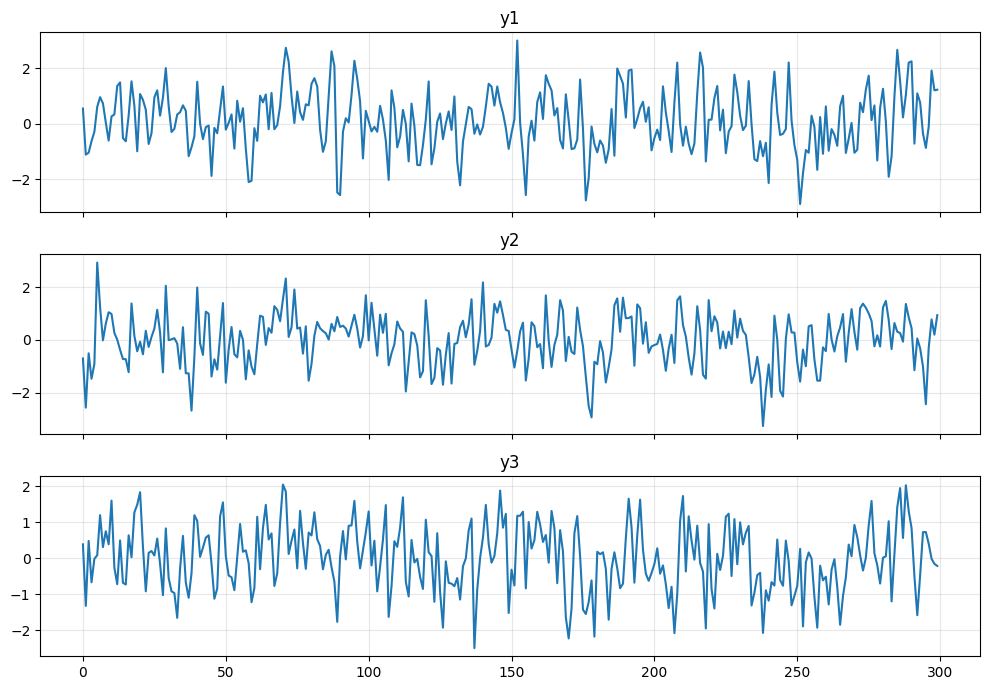

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

def companion_matrix(A_list):
    """
    Build the VAR(p) companion matrix for coefficient matrices A_1, ..., A_p.
    
    Parameters
    ----------
    A_list : list of np.ndarray
        Each element is (k x k), where k is the number of variables.
    
    Returns
    -------
    F : np.ndarray
        Companion matrix of shape (k*p, k*p).
    """
    p = len(A_list)
    k = A_list[0].shape[0]
    
    top_block = np.hstack(A_list)
    if p == 1:
        return top_block
    
    lower_block = np.hstack([
        np.eye(k * (p - 1)),
        np.zeros((k * (p - 1), k))
    ])
    F = np.vstack([top_block, lower_block])
    return F


def is_var_stable(A_list, tol=0.999):
    """
    Check VAR stability via companion matrix eigenvalues.
    
    A VAR is stable if all eigenvalues of the companion matrix
    lie strictly inside the unit circle.
    """
    F = companion_matrix(A_list)
    eigvals = np.linalg.eigvals(F)
    max_modulus = np.max(np.abs(eigvals))
    return max_modulus < tol, max_modulus, eigvals


def simulate_var(A_list, Sigma, T, burnin=200, seed=123):
    """
    Simulate a VAR(p):
        y_t = A_1 y_{t-1} + ... + A_p y_{t-p} + u_t
    
    Parameters
    ----------
    A_list : list of np.ndarray
        VAR coefficient matrices [A_1, ..., A_p], each (k x k).
    Sigma : np.ndarray
        Innovation covariance matrix (k x k).
    T : int
        Number of retained observations after burn-in.
    burnin : int
        Number of initial observations discarded.
    seed : int
        Random seed.
    
    Returns
    -------
    Y : np.ndarray
        Simulated data of shape (T, k).
    """
    local_rng = np.random.default_rng(seed)
    p = len(A_list)
    k = A_list[0].shape[0]
    total_T = T + burnin
    
    Y = np.zeros((total_T + p, k))
    shocks = local_rng.multivariate_normal(mean=np.zeros(k), cov=Sigma, size=total_T)
    
    for t in range(p, total_T + p):
        y_t = np.zeros(k)
        for lag in range(1, p + 1):
            y_t += A_list[lag - 1] @ Y[t - lag]
        y_t += shocks[t - p]
        Y[t] = y_t
    
    return Y[p + burnin:]


# -----------------------------
# Specify a stable VAR(2) DGP
# -----------------------------
k = 3
p = 2
T = 300

A1 = np.array([
    [0.50, 0.10, 0.00],
    [0.05, 0.40, 0.10],
    [0.00, 0.10, 0.35]
])

A2 = np.array([
    [-0.20, 0.00, 0.05],
    [0.00, -0.15, 0.00],
    [0.05, 0.00, -0.10]
])

Sigma = np.array([
    [1.00, 0.30, 0.20],
    [0.30, 0.80, 0.25],
    [0.20, 0.25, 0.60]
])

stable, max_modulus, eigvals = is_var_stable([A1, A2])
print(f"Stable VAR: {stable}")
print(f"Max eigenvalue modulus: {max_modulus:.4f}")

if not stable:
    raise ValueError("Chosen VAR coefficients are not stable. Adjust A1/A2 before continuing.")

Y = simulate_var([A1, A2], Sigma, T=T, burnin=300, seed=GLOBAL_SEED)

columns = [f"y{i+1}" for i in range(k)]
df = pd.DataFrame(Y, columns=columns)
df.index.name = "time"

print("\nSimulated data shape:", df.shape)
display(df.head())

# Quick visualization
fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)
for i, col in enumerate(columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Build the VAR Design Matrix

To estimate a VAR$(p)$ from scratch, we rewrite the system in multivariate regression form:

$
Y = X B + U
$

where:

- $Y$ is the matrix of responses
- $X$ contains lagged values (and optionally an intercept)
- $B$ is the coefficient matrix
- $U$ is the innovation matrix

For a VAR $(p)$ with $k$ variables and $T$ observations, each row of $X$ contains:

$
[1,\ y_{t-1}^\top,\ y_{t-2}^\top,\ \dots,\ y_{t-p}^\top]
$

if an intercept is included.

This cell constructs the regression matrices carefully and checks dimensions.

In [3]:
def build_var_regression_matrices(Y, p, include_intercept=True):
    """
    Construct regression matrices for a VAR(p):
        Y_target = X @ B + U

    Parameters
    ----------
    Y : np.ndarray
        Array of shape (T, k), where T is the number of time points
        and k is the number of variables.
    p : int
        Number of lags.
    include_intercept : bool
        Whether to include an intercept column in X.

    Returns
    -------
    Y_target : np.ndarray
        Target matrix of shape (T - p, k).
    X : np.ndarray
        Regressor matrix of shape (T - p, m), where
        m = 1 + k*p if include_intercept else k*p.
    feature_names : list of str
        Names for columns of X, useful for debugging.
    """
    Y = np.asarray(Y)
    T, k = Y.shape

    if T <= p:
        raise ValueError(f"Need T > p, but got T={T}, p={p}")

    X_rows = []
    Y_rows = []
    feature_names = []

    if include_intercept:
        feature_names.append("const")

    for lag in range(1, p + 1):
        for j in range(k):
            feature_names.append(f"y{j+1}_lag{lag}")

    for t in range(p, T):
        row = []

        if include_intercept:
            row.append(1.0)

        for lag in range(1, p + 1):
            row.extend(Y[t - lag, :])

        X_rows.append(row)
        Y_rows.append(Y[t, :])

    X = np.array(X_rows)
    Y_target = np.array(Y_rows)

    return Y_target, X, feature_names


# Build matrices for the simulated dataset
Y_target, X, feature_names = build_var_regression_matrices(
    Y=df.values,
    p=p,
    include_intercept=True
)

print("Y_target shape:", Y_target.shape)
print("X shape:", X.shape)
print("Number of features:", len(feature_names))
print("\nFirst 10 feature names:")
print(feature_names[:10])

# Wrap in DataFrames for easier inspection
X_df = pd.DataFrame(X, columns=feature_names)
Y_target_df = pd.DataFrame(Y_target, columns=columns)

print("\nFirst few rows of X:")
display(X_df.head())

print("\nFirst few rows of Y_target:")
display(Y_target_df.head())

# Sanity checks
T_eff = len(df) - p
expected_num_features = 1 + k * p
assert Y_target.shape == (T_eff, k), "Y_target has incorrect shape"
assert X.shape == (T_eff, expected_num_features), "X has incorrect shape"

print("\nSanity checks passed.")

# Manual row check for debugging
row_idx = 0
print("\nManual row check:")
print("Target time index in original data:", p + row_idx)
print("Y_target first row:", Y_target[row_idx])

print("\nExpected lagged values from original data:")
for lag in range(1, p + 1):
    print(f"lag {lag}:", df.values[p + row_idx - lag])

print("\nConstructed X first row:")
print(X[row_idx])

Y_target shape: (298, 3)
X shape: (298, 7)
Number of features: 7

First 10 feature names:
['const', 'y1_lag1', 'y2_lag1', 'y3_lag1', 'y1_lag2', 'y2_lag2', 'y3_lag2']

First few rows of X:


,const,y1_lag1,y2_lag1,y3_lag1,y1_lag2,y2_lag2,y3_lag2
0,1.0,-1.110253,-2.564039,-1.328354,0.551738,-0.703764,0.380809
1,1.0,-1.040441,-0.507790,0.476514,-1.110253,-2.564039,-1.328354
2,1.0,-0.627772,-1.469973,-0.671117,-1.040441,-0.507790,0.476514
3,1.0,-0.288088,-0.916778,-0.020670,-0.627772,-1.469973,-0.671117
4,1.0,0.612900,2.925630,0.079928,-0.288088,-0.916778,-0.020670



First few rows of Y_target:


,y1,y2,y3
0,-1.040441,-0.507790,0.476514
1,-0.627772,-1.469973,-0.671117
2,-0.288088,-0.916778,-0.020670
3,0.612900,2.925630,0.079928
4,0.962058,1.244282,1.192399



Sanity checks passed.

Manual row check:
Target time index in original data: 2
Y_target first row: [-1.04044102 -0.50779037  0.47651368]

Expected lagged values from original data:
lag 1: [-1.11025314 -2.56403915 -1.32835395]
lag 2: [ 0.55173819 -0.70376446  0.38080873]

Constructed X first row:
[ 1.         -1.11025314 -2.56403915 -1.32835395  0.55173819 -0.70376446
  0.38080873]


## Estimating a VAR(p) via Multivariate OLS

With the regression matrices constructed, we can estimate the VAR parameters directly using multivariate ordinary least squares.

The VAR can be written in stacked regression form:

$
Y = X B + U
$

where

- $Y$ : $(T-p) \times k$ matrix of observed responses  
- $X$ : $(T-p) \times (1 + kp)$ matrix of regressors (lags and intercept)  
- $B$ : $(1 + kp) \times k$ coefficient matrix  
- $U$ : $(T-p) \times k$ innovation matrix

Each column of $B$ corresponds to one equation of the VAR system.

The OLS estimator is

$
\hat{B} = (X'X)^{-1}X'Y
$

From $\hat{B}$ we recover:

- the intercept vector
- the lag coefficient matrices  
  $
  A_1, A_2, \dots, A_p
  $

where each $A_i$ is a $k \times k$ matrix describing how the $i$-th lag affects the system.

After estimation we also compute:

**Residuals**

$
\hat{U} = Y - X\hat{B}
$

**Innovation covariance**

$
\hat{\Sigma} = \frac{1}{T-p} \hat{U}'\hat{U}
$

This covariance matrix represents the estimated shock distribution of the VAR.

Finally, we verify that the **estimated VAR is stable** by checking the eigenvalues of the companion matrix. Stability requires

$
|\lambda_i| < 1
$

for all eigenvalues.

The following cell implements the full VAR estimation pipeline from scratch.

VAR(p) OLS ESTIMATION RESULTS
Number of variables (k): 3
Lag order (p): 2
Effective sample size: 298
Number of regressors per equation: 7

Estimated intercept vector:
[ 0.1056 -0.0068  0.0034]

Estimated A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]

Estimated A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]

Estimated innovation covariance Sigma_hat:
[[0.9274 0.3144 0.2276]
 [0.3144 0.8313 0.2886]
 [0.2276 0.2886 0.73  ]]

COMPARISON TO TRUE DGP
True A1:
[[0.5  0.1  0.  ]
 [0.05 0.4  0.1 ]
 [0.   0.1  0.35]]
Estimated A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]
A1 estimation error (Frobenius norm): 0.1855

True A2:
[[-0.2   0.    0.05]
 [ 0.   -0.15  0.  ]
 [ 0.05  0.   -0.1 ]]
Estimated A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]
A2 estimation error (Frobenius norm): 0.1515

True Sigma:
[[1.   0.3  0.2 ]
 [0.3  0.8  0.25]
 [0.2  0.25 0.6 ]]
Es

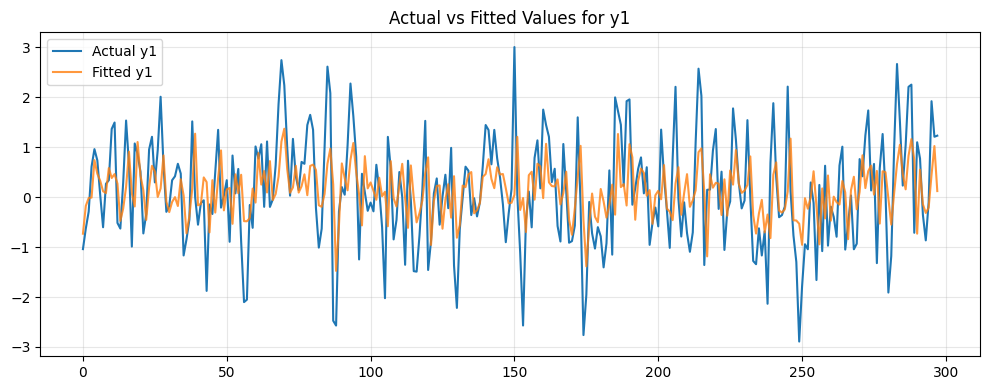

In [4]:
def fit_var_ols(Y, p, include_intercept=True):
    """
    Fit a VAR(p) by multivariate OLS:
        Y_target = X B + U

    Parameters
    ----------
    Y : np.ndarray
        Array of shape (T, k).
    p : int
        Number of lags.
    include_intercept : bool
        Whether to include an intercept.

    Returns
    -------
    results : dict
        Dictionary containing:
        - B_hat: OLS coefficient matrix
        - residuals: fitted residuals
        - Sigma_hat: residual covariance estimate
        - Y_target, X, feature_names
        - intercept
        - A_hat_list
        - fitted_values
    """
    Y_target, X, feature_names = build_var_regression_matrices(
        Y=Y, p=p, include_intercept=include_intercept
    )

    XtX = X.T @ X
    XtY = X.T @ Y_target
    B_hat = np.linalg.solve(XtX, XtY)

    fitted_values = X @ B_hat
    residuals = Y_target - fitted_values

    T_eff, k = Y_target.shape
    m = X.shape[1]

    # MLE-style covariance estimate
    Sigma_hat = (residuals.T @ residuals) / T_eff

    row_idx = 0
    intercept = None
    if include_intercept:
        intercept = B_hat[0, :]
        row_idx = 1

    A_hat_list = []
    for lag in range(p):
        block = B_hat[row_idx + lag * k : row_idx + (lag + 1) * k, :]
        # block is arranged with predictors in rows, equations in columns
        # transpose so A_hat maps y_{t-lag} -> y_t
        A_hat_list.append(block.T)

    return {
        "B_hat": B_hat,
        "residuals": residuals,
        "Sigma_hat": Sigma_hat,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "intercept": intercept,
        "A_hat_list": A_hat_list,
        "fitted_values": fitted_values,
    }


# -----------------------------
# Fit the VAR(2) by OLS
# -----------------------------
var_ols_results = fit_var_ols(df.values, p=p, include_intercept=True)

B_hat = var_ols_results["B_hat"]
A_hat_list = var_ols_results["A_hat_list"]
Sigma_hat = var_ols_results["Sigma_hat"]
intercept_hat = var_ols_results["intercept"]
residuals_hat = var_ols_results["residuals"]

print("=" * 80)
print("VAR(p) OLS ESTIMATION RESULTS")
print("=" * 80)
print(f"Number of variables (k): {k}")
print(f"Lag order (p): {p}")
print(f"Effective sample size: {var_ols_results['Y_target'].shape[0]}")
print(f"Number of regressors per equation: {var_ols_results['X'].shape[1]}")
print()

print("Estimated intercept vector:")
print(np.round(intercept_hat, 4))
print()

for lag, A_hat in enumerate(A_hat_list, start=1):
    print(f"Estimated A{lag}:")
    print(np.round(A_hat, 4))
    print()

print("Estimated innovation covariance Sigma_hat:")
print(np.round(Sigma_hat, 4))
print()

print("=" * 80)
print("COMPARISON TO TRUE DGP")
print("=" * 80)

true_A_list = [A1, A2]
for lag, (A_true, A_hat) in enumerate(zip(true_A_list, A_hat_list), start=1):
    print(f"True A{lag}:")
    print(np.round(A_true, 4))
    print(f"Estimated A{lag}:")
    print(np.round(A_hat, 4))
    print(f"A{lag} estimation error (Frobenius norm): {np.linalg.norm(A_hat - A_true):.4f}")
    print()

print("True Sigma:")
print(np.round(Sigma, 4))
print("Estimated Sigma_hat:")
print(np.round(Sigma_hat, 4))
print(f"Sigma estimation error (Frobenius norm): {np.linalg.norm(Sigma_hat - Sigma):.4f}")
print()

stable_hat, max_modulus_hat, eigvals_hat = is_var_stable(A_hat_list)
print("=" * 80)
print("STABILITY CHECK FOR ESTIMATED VAR")
print("=" * 80)
print(f"Estimated VAR stable: {stable_hat}")
print(f"Estimated companion max eigenvalue modulus: {max_modulus_hat:.4f}")
print()

# Optional: fitted vs actual quick visual check for first variable
fitted_df = pd.DataFrame(
    var_ols_results["fitted_values"],
    columns=[f"{col}_fitted" for col in columns]
)
actual_df = pd.DataFrame(
    var_ols_results["Y_target"],
    columns=columns
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(actual_df.index, actual_df["y1"], label="Actual y1")
ax.plot(fitted_df.index, fitted_df["y1_fitted"], label="Fitted y1", alpha=0.8)
ax.set_title("Actual vs Fitted Values for y1")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Multi-Step Forecasting with the Estimated VAR

Once the VAR$(p)$ parameters are estimated, forecasts can be generated recursively using the fitted model.

Recall the VAR system:

$
y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + \dots + A_p y_{t-p} + u_t
$

For point forecasting we assume the future shocks have expectation zero:

$
E[u_{t+h}] = 0
$

Therefore the **forecast recursion** becomes:

$
\hat{y}_{t+h} =
c + A_1 \hat{y}_{t+h-1}
+ A_2 \hat{y}_{t+h-2}
+ \dots
+ A_p \hat{y}_{t+h-p}
$

Key idea:

- The first forecast uses **actual observed lags**
- Later forecasts use **previous forecasts as inputs**

Example:

1-step ahead:

$
\hat{y}_{t+1} =
c + A_1 y_t + A_2 y_{t-1}
$

2-step ahead:

$
\hat{y}_{t+2} =
c + A_1 \hat{y}_{t+1} + A_2 y_t
$

3-step ahead:

$
\hat{y}_{t+3} =
c + A_1 \hat{y}_{t+2} + A_2 \hat{y}_{t+1}
$

This recursive structure is fundamental to all VAR-based forecasting methods.

In this cell we:

• Use the final $p$ observations of the dataset as the **forecast history**  
• Generate an **$h$-step-ahead forecast path**  
• Plot the forecasts alongside recent observed data  

These point forecasts serve as the baseline before later adding:

- predictive intervals
- rolling forecasts
- Bayesian posterior forecasting
- distributionally robust forecasts.

VAR POINT FORECAST EXAMPLE
Using the last 2 observed time points as forecast history
History used for forecasting:


,y1,y2,y3
t-1,1.209753,0.198130,-0.160984
t,1.231485,0.935197,-0.216770


Forecast path:


,y1_forecast,y2_forecast,y3_forecast
1,0.361628,0.390710,0.093630
2,-0.048046,0.120801,0.105099
3,0.025594,0.007668,0.042330
4,0.141599,-0.013460,0.007836
5,0.160141,0.000854,0.005313
6,0.138073,0.011926,0.011610
7,0.126015,0.013056,0.014503
8,0.127182,0.010986,0.014136
9,0.130513,0.010017,0.013360
10,0.131407,0.010171,0.013185


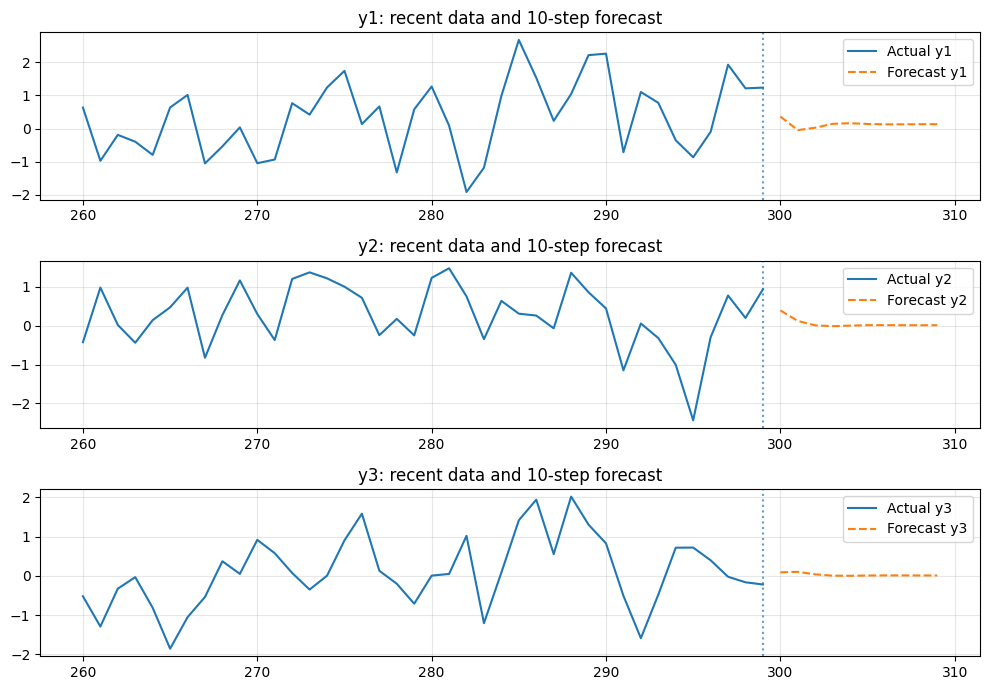

In [5]:
def var_forecast(A_list, intercept, y_history, h):
    """
    Multi-step forecast for a fitted VAR(p).

    Parameters
    ----------
    A_list : list of np.ndarray
        Estimated VAR coefficient matrices [A1, ..., Ap], each (k x k).
    intercept : np.ndarray or None
        Intercept vector of shape (k,).
    y_history : np.ndarray
        Most recent observed history of shape (p, k), ordered oldest -> newest.
    h : int
        Forecast horizon.

    Returns
    -------
    forecasts : np.ndarray
        Array of shape (h, k) containing point forecasts.
    """
    p = len(A_list)
    k = A_list[0].shape[0]

    if y_history.shape != (p, k):
        raise ValueError(f"y_history must have shape {(p, k)}, got {y_history.shape}")

    history = [row.copy() for row in y_history]
    forecasts = []

    const = np.zeros(k) if intercept is None else intercept.copy()

    for step in range(h):
        y_next = const.copy()
        for lag in range(1, p + 1):
            y_next += A_list[lag - 1] @ history[-lag]
        forecasts.append(y_next)
        history.append(y_next)

    return np.array(forecasts)


# -----------------------------------------------------------------------------
# Example: produce 10-step-ahead forecasts from the fitted VAR using final p obs
# -----------------------------------------------------------------------------
h = 10
y_history = df.values[-p:, :]   # last p observations, ordered oldest -> newest
forecast_path = var_forecast(
    A_list=A_hat_list,
    intercept=intercept_hat,
    y_history=y_history,
    h=h
)

forecast_df = pd.DataFrame(
    forecast_path,
    columns=[f"{col}_forecast" for col in columns],
    index=np.arange(1, h + 1)
)

print("=" * 80)
print("VAR POINT FORECAST EXAMPLE")
print("=" * 80)
print(f"Using the last {p} observed time points as forecast history")
print("History used for forecasting:")
display(pd.DataFrame(y_history, columns=columns, index=[f"t-{p-1}", f"t"] if p == 2 else None))

print("Forecast path:")
display(forecast_df)

# Plot recent history + forecasts for each variable
plot_window = 40
recent_actual = df.iloc[-plot_window:].copy()

fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=False)

for i, col in enumerate(columns):
    axes[i].plot(
        recent_actual.index,
        recent_actual[col],
        label=f"Actual {col}"
    )
    axes[i].plot(
        np.arange(recent_actual.index[-1] + 1, recent_actual.index[-1] + h + 1),
        forecast_df[f"{col}_forecast"].values,
        label=f"Forecast {col}",
        linestyle="--"
    )
    axes[i].axvline(recent_actual.index[-1], linestyle=":", alpha=0.7)
    axes[i].set_title(f"{col}: recent data and {h}-step forecast")
    axes[i].grid(alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Rolling Forecast Evaluation for the VAR

A single forecast path from the end of the sample is useful for illustration, but it is not enough to evaluate forecasting performance.

To assess how the VAR performs in practice, we use a **rolling forecast experiment**:

1. Choose an initial training window
2. Re-estimate the VAR on that window
3. Produce an $h$-step-ahead forecast
4. Move the training window forward by one period
5. Repeat until the sample is exhausted

This produces a sequence of pseudo out-of-sample forecasts and allows us to measure forecast accuracy in a realistic way.

For now we focus on **point forecasts**. Later we will extend this to:

- predictive intervals
- log predictive density
- forecast stability and reproducibility diagnostics

The main metrics in this cell are:

**Root Mean Squared Error**
$
\mathrm{RMSE}_j = \sqrt{\frac{1}{N}\sum_{i=1}^N (\hat y_{i,j} - y_{i,j})^2}
$

**Mean Absolute Error**
$
\mathrm{MAE}_j = \frac{1}{N}\sum_{i=1}^N |\hat y_{i,j} - y_{i,j}|
$

where $j$ indexes the variable and $N$ is the number of forecast origins.

This gives a first honest check of whether the fitted VAR is recovering the dynamics of the simulated system well enough to forecast out of sample.

ROLLING VAR FORECAST RESULTS
Forecast horizon: 1
Initial training size: 220
Number of rolling forecasts: 80

First few rolling forecast records:


,forecast_origin,target_time,horizon,y1_actual,y1_forecast,y1_error,y2_actual,y2_forecast,y2_error,y3_actual,y3_forecast,y3_error
0,219,220,1,0.152819,0.569237,0.416419,0.327796,0.753561,0.425765,-0.858689,0.698960,1.557649
1,220,221,1,0.930831,0.176904,-0.753927,0.894734,-0.228409,-1.123143,-1.400108,-0.282934,1.117173
2,221,222,1,1.364409,0.362121,-1.002288,0.659352,0.284323,-0.375029,0.118330,-0.239499,-0.357828
3,222,223,1,-0.234954,0.466182,0.701136,-0.323173,0.519106,0.842279,-0.330053,0.248051,0.578104
4,223,224,1,0.510563,-0.346546,-0.857109,0.315203,-0.044828,-0.360031,0.061603,-0.097886,-0.159489


Point forecast metrics:


,variable,RMSE,MAE
0,y1,1.026098,0.851606
1,y2,0.930923,0.747469
2,y3,0.842204,0.679864


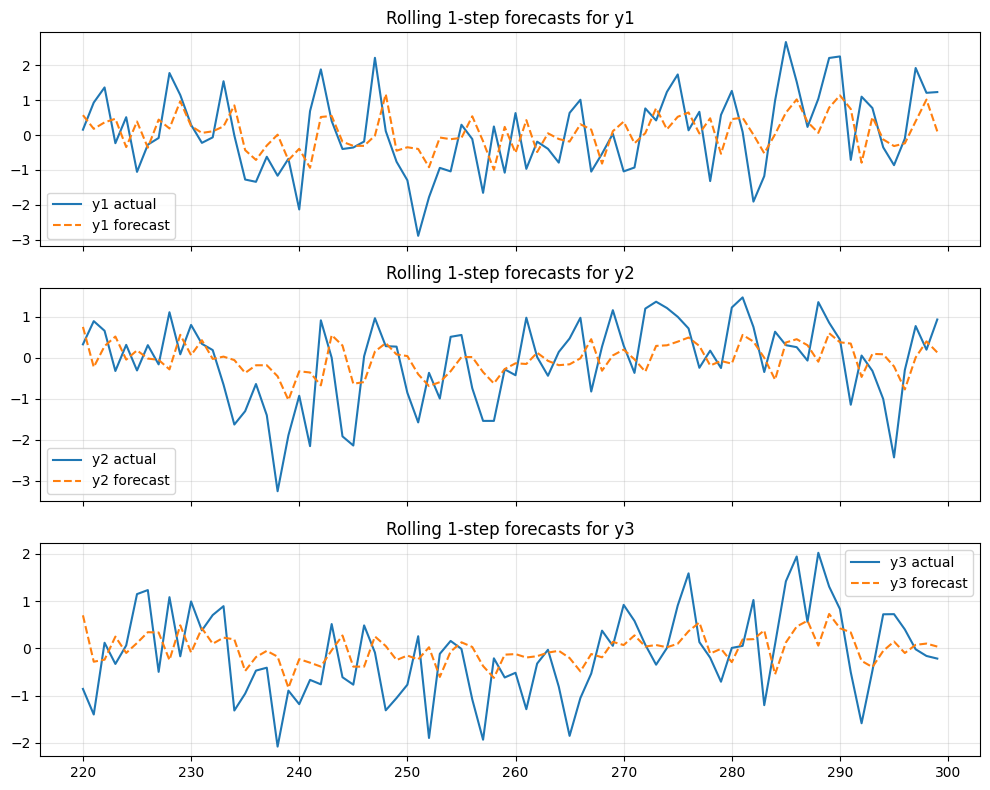

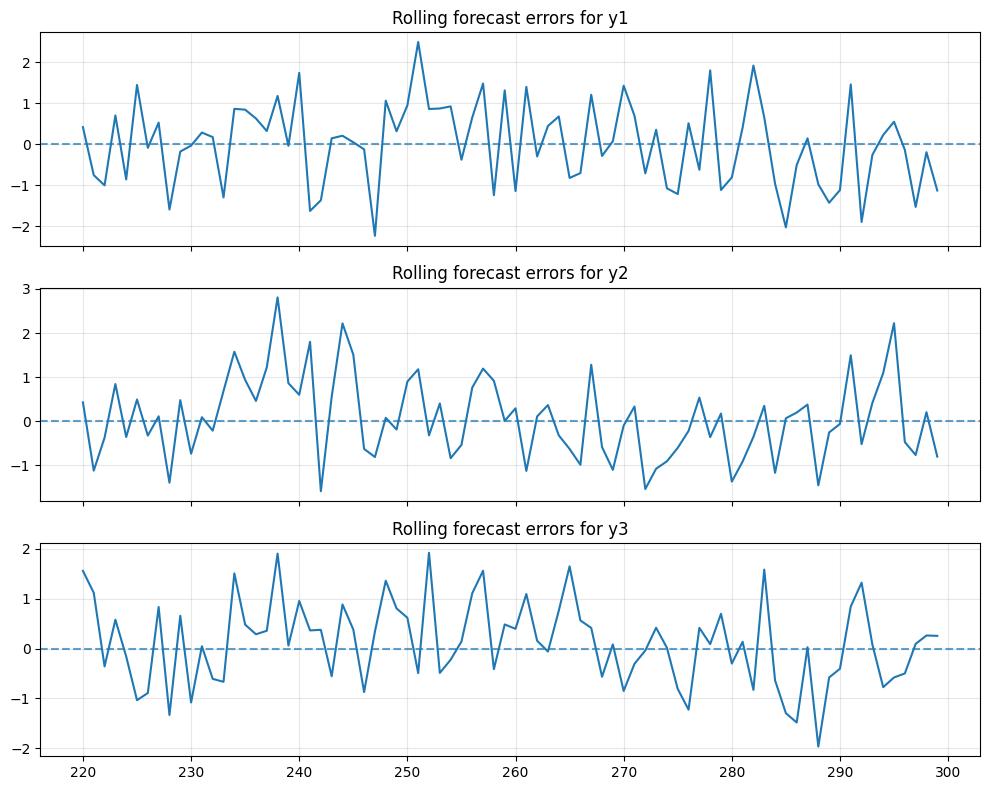

REPRODUCIBILITY CHECK
Repeated run gives identical forecasts: True


In [6]:
def rolling_var_forecast(Y, p, h=1, train_size=200, include_intercept=True):
    """
    Rolling pseudo out-of-sample forecasts for a VAR(p).

    Parameters
    ----------
    Y : np.ndarray
        Full dataset of shape (T, k).
    p : int
        VAR lag order.
    h : int
        Forecast horizon.
    train_size : int
        Number of observations in the initial training window.
    include_intercept : bool
        Whether to include an intercept in the VAR.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with forecast origin, target time, actual values, and forecasts.
    """
    Y = np.asarray(Y)
    T, k = Y.shape

    if train_size <= p:
        raise ValueError("train_size must be greater than p")
    if train_size + h > T:
        raise ValueError("Not enough data for the requested train_size and horizon")

    records = []

    for train_end in range(train_size, T - h + 1):
        Y_train = Y[:train_end, :]
        fit = fit_var_ols(Y_train, p=p, include_intercept=include_intercept)

        y_history = Y_train[-p:, :]
        fcst = var_forecast(
            A_list=fit["A_hat_list"],
            intercept=fit["intercept"],
            y_history=y_history,
            h=h
        )

        y_pred = fcst[-1, :]
        y_true = Y[train_end + h - 1, :]

        row = {
            "forecast_origin": train_end - 1,
            "target_time": train_end + h - 1,
            "horizon": h
        }

        for j in range(k):
            row[f"y{j+1}_actual"] = y_true[j]
            row[f"y{j+1}_forecast"] = y_pred[j]
            row[f"y{j+1}_error"] = y_pred[j] - y_true[j]

        records.append(row)

    return pd.DataFrame(records)


def compute_point_forecast_metrics(results_df, k):
    """
    Compute RMSE and MAE for each variable from rolling forecast results.
    """
    rows = []
    for j in range(1, k + 1):
        err = results_df[f"y{j}_error"].values
        rmse = np.sqrt(np.mean(err**2))
        mae = np.mean(np.abs(err))
        rows.append({
            "variable": f"y{j}",
            "RMSE": rmse,
            "MAE": mae
        })
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# Run a 1-step-ahead rolling forecast experiment on the simulated VAR
# ------------------------------------------------------------------
h_roll = 1
train_size = 220

rolling_results = rolling_var_forecast(
    Y=df.values,
    p=p,
    h=h_roll,
    train_size=train_size,
    include_intercept=True
)

metrics_df = compute_point_forecast_metrics(rolling_results, k=k)

print("=" * 80)
print("ROLLING VAR FORECAST RESULTS")
print("=" * 80)
print(f"Forecast horizon: {h_roll}")
print(f"Initial training size: {train_size}")
print(f"Number of rolling forecasts: {len(rolling_results)}")
print()

print("First few rolling forecast records:")
display(rolling_results.head())

print("Point forecast metrics:")
display(metrics_df)

# Plot actual vs forecast for each variable across rolling targets
fig, axes = plt.subplots(k, 1, figsize=(10, 8), sharex=True)

for j in range(1, k + 1):
    ax = axes[j - 1]
    ax.plot(
        rolling_results["target_time"],
        rolling_results[f"y{j}_actual"],
        label=f"y{j} actual"
    )
    ax.plot(
        rolling_results["target_time"],
        rolling_results[f"y{j}_forecast"],
        label=f"y{j} forecast",
        linestyle="--"
    )
    ax.set_title(f"Rolling 1-step forecasts for y{j}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Plot forecast errors
fig, axes = plt.subplots(k, 1, figsize=(10, 8), sharex=True)

for j in range(1, k + 1):
    ax = axes[j - 1]
    ax.plot(
        rolling_results["target_time"],
        rolling_results[f"y{j}_error"]
    )
    ax.axhline(0.0, linestyle="--", alpha=0.7)
    ax.set_title(f"Rolling forecast errors for y{j}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
print("REPRODUCIBILITY CHECK")
print("=" * 80)
rolling_results_2 = rolling_var_forecast(
    Y=df.values,
    p=p,
    h=h_roll,
    train_size=train_size,
    include_intercept=True
)

same_results = np.allclose(
    rolling_results.filter(like="_forecast").values,
    rolling_results_2.filter(like="_forecast").values
)

print(f"Repeated run gives identical forecasts: {same_results}")

## Predictive Intervals and Log Predictive Density

So far we evaluated only **point forecasts**. However, VAR models also produce a **predictive distribution**.

Under the classical VAR assumption:

$
u_t \sim \mathcal{N}(0,\Sigma)
$

the **1-step-ahead predictive distribution** is

$
y_{t+1} \mid \mathcal{F}_t
\sim
\mathcal{N}(\hat{y}_{t+1}, \Sigma)
$

where

- $\hat{y}_{t+1}$ is the point forecast
- $\Sigma$ is the innovation covariance matrix estimated from residuals.

This allows us to compute:

### Predictive Intervals

For each variable:

$
\hat{y}_{t+1,j} \pm z_{\alpha/2} \sqrt{\Sigma_{jj}}
$

We will compute **95% predictive intervals**.

### Predictive Interval Coverage

Coverage measures whether the true value falls inside the interval:

$
\text{coverage} =
\frac{\#\{y_t \in \text{interval}\}}{N}
$

A well calibrated model should achieve coverage close to the nominal level.

### Log Predictive Density

For each observation:

$
\log p(y_t | \mathcal{F}_{t-1})
$

This evaluates the **full predictive distribution**, not just the mean.

Log predictive density is widely used in macroeconometric forecast comparisons.

PREDICTIVE INTERVAL COVERAGE


,variable,coverage
0,y1,0.9375
1,y2,0.9500
2,y3,0.9625


LOG PREDICTIVE DENSITY
Average log predictive density: -3.9195559143944174


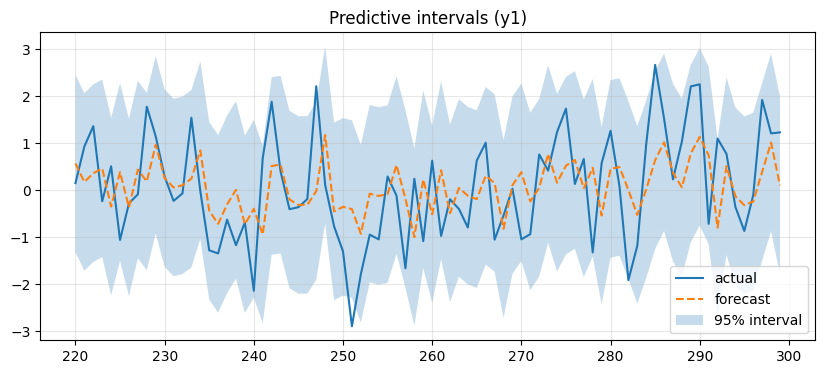

In [10]:
from scipy.stats import norm, multivariate_normal

def compute_predictive_intervals(rolling_df, Sigma_hat, alpha=0.05):
    """
    Compute predictive intervals and coverage for rolling forecasts.
    """
    k = Sigma_hat.shape[0]
    z = norm.ppf(1 - alpha / 2)

    results = rolling_df.copy()

    for j in range(1, k + 1):

        sigma = np.sqrt(Sigma_hat[j - 1, j - 1])

        lower = results[f"y{j}_forecast"] - z * sigma
        upper = results[f"y{j}_forecast"] + z * sigma

        results[f"y{j}_lower"] = lower
        results[f"y{j}_upper"] = upper

        actual = results[f"y{j}_actual"]

        inside = (actual >= lower) & (actual <= upper)
        results[f"y{j}_covered"] = inside.astype(int)

    return results


def compute_interval_coverage(results_df, k):

    rows = []

    for j in range(1, k + 1):

        coverage = results_df[f"y{j}_covered"].mean()

        rows.append({
            "variable": f"y{j}",
            "coverage": coverage
        })

    return pd.DataFrame(rows)


def compute_log_predictive_density(results_df, Sigma_hat):

    k = Sigma_hat.shape[0]
    log_scores = []

    for i in range(len(results_df)):

        forecast = np.array([
            results_df[f"y{j}_forecast"].iloc[i]
            for j in range(1, k + 1)
        ])

        actual = np.array([
            results_df[f"y{j}_actual"].iloc[i]
            for j in range(1, k + 1)
        ])

        logp = multivariate_normal.logpdf(
            actual,
            mean=forecast,
            cov=Sigma_hat
        )

        log_scores.append(logp)

    return np.array(log_scores)


# -------------------------------------------------------
# Compute predictive intervals
# -------------------------------------------------------

interval_results = compute_predictive_intervals(
    rolling_results,
    Sigma_hat
)

coverage_df = compute_interval_coverage(interval_results, k)

print("="*80)
print("PREDICTIVE INTERVAL COVERAGE")
print("="*80)
display(coverage_df)

# -------------------------------------------------------
# Log predictive density
# -------------------------------------------------------

log_scores = compute_log_predictive_density(
    interval_results,
    Sigma_hat
)

print("="*80)
print("LOG PREDICTIVE DENSITY")
print("="*80)

print("Average log predictive density:", np.mean(log_scores))


# -------------------------------------------------------
# Plot intervals for first variable
# -------------------------------------------------------

plt.figure(figsize=(10,4))

plt.plot(
    interval_results["target_time"],
    interval_results["y1_actual"],
    label="actual"
)

plt.plot(
    interval_results["target_time"],
    interval_results["y1_forecast"],
    label="forecast",
    linestyle="--"
)

plt.fill_between(
    interval_results["target_time"],
    interval_results["y1_lower"],
    interval_results["y1_upper"],
    alpha=0.25,
    label="95% interval"
)

plt.legend()
plt.title("Predictive intervals (y1)")
plt.grid(alpha=0.3)

plt.show()

## Lightweight Unit Tests for VAR Stability, Stationarity, and Reproducibility

Before moving on, it is useful to add a few lightweight tests that verify the implementation is behaving as expected.

These are not formal package tests, but they help confirm that the core mechanics are correct and reproducible.

We check:

1. **Estimated VAR stability**  
   The estimated companion matrix should have all eigenvalues inside the unit circle.

2. **Innovation covariance validity**  
   The estimated covariance matrix should be symmetric and positive definite.

3. **Forecast reproducibility**  
   Re-running deterministic VAR estimation and forecasting on the same data should give identical results.

4. **Regression-matrix consistency**  
   The dimensions of the design matrix and response matrix should remain valid.

These checks are especially useful before extending the workflow to Bayesian estimation and later to distributionally robust forecasting.

In [11]:
def run_var_sanity_checks(df, p, include_intercept=True, h=5):
    """
    Run lightweight sanity/unit checks for the VAR implementation.
    """
    print("=" * 80)
    print("RUNNING VAR SANITY CHECKS")
    print("=" * 80)

    Y = df.values

    # -----------------------------
    # 1) Build regression matrices
    # -----------------------------
    Y_target_chk, X_chk, feature_names_chk = build_var_regression_matrices(
        Y=Y, p=p, include_intercept=include_intercept
    )

    T, k_local = Y.shape
    expected_rows = T - p
    expected_cols = (1 if include_intercept else 0) + k_local * p

    print("[1] Regression matrix dimensions")
    print(f"Expected Y_target shape: ({expected_rows}, {k_local})")
    print(f"Actual   Y_target shape: {Y_target_chk.shape}")
    print(f"Expected X shape: ({expected_rows}, {expected_cols})")
    print(f"Actual   X shape: {X_chk.shape}")

    assert Y_target_chk.shape == (expected_rows, k_local), "Y_target shape mismatch"
    assert X_chk.shape == (expected_rows, expected_cols), "X shape mismatch"
    print("PASS: Regression matrix dimensions are correct.\n")

    # -----------------------------
    # 2) Fit VAR twice
    # -----------------------------
    fit1 = fit_var_ols(Y, p=p, include_intercept=include_intercept)
    fit2 = fit_var_ols(Y, p=p, include_intercept=include_intercept)

    print("[2] Reproducibility of deterministic VAR estimation")
    same_B = np.allclose(fit1["B_hat"], fit2["B_hat"])
    same_Sigma = np.allclose(fit1["Sigma_hat"], fit2["Sigma_hat"])
    print(f"B_hat identical across repeated runs: {same_B}")
    print(f"Sigma_hat identical across repeated runs: {same_Sigma}")

    assert same_B, "B_hat is not reproducible"
    assert same_Sigma, "Sigma_hat is not reproducible"
    print("PASS: VAR estimation is reproducible.\n")

    # -----------------------------
    # 3) Stability check
    # -----------------------------
    print("[3] Stability / stationarity check")
    stable_chk, max_modulus_chk, eigvals_chk = is_var_stable(fit1["A_hat_list"])
    print(f"Estimated VAR stable: {stable_chk}")
    print(f"Maximum eigenvalue modulus: {max_modulus_chk:.6f}")

    assert stable_chk, "Estimated VAR is not stable"
    print("PASS: Estimated VAR is stable.\n")

    # -----------------------------
    # 4) Covariance validity
    # -----------------------------
    print("[4] Innovation covariance checks")
    Sigma_chk = fit1["Sigma_hat"]

    symmetric_chk = np.allclose(Sigma_chk, Sigma_chk.T)
    eigvals_sigma = np.linalg.eigvalsh(Sigma_chk)
    posdef_chk = np.all(eigvals_sigma > 0)

    print(f"Sigma_hat symmetric: {symmetric_chk}")
    print(f"Sigma_hat eigenvalues: {np.round(eigvals_sigma, 6)}")
    print(f"Sigma_hat positive definite: {posdef_chk}")

    assert symmetric_chk, "Sigma_hat is not symmetric"
    assert posdef_chk, "Sigma_hat is not positive definite"
    print("PASS: Sigma_hat is a valid covariance matrix.\n")

    # -----------------------------
    # 5) Forecast reproducibility
    # -----------------------------
    print("[5] Forecast reproducibility")
    y_history_chk = Y[-p:, :]

    fcst1 = var_forecast(
        A_list=fit1["A_hat_list"],
        intercept=fit1["intercept"],
        y_history=y_history_chk,
        h=h
    )

    fcst2 = var_forecast(
        A_list=fit2["A_hat_list"],
        intercept=fit2["intercept"],
        y_history=y_history_chk,
        h=h
    )

    same_fcst = np.allclose(fcst1, fcst2)
    print(f"{h}-step forecasts identical across repeated runs: {same_fcst}")

    assert same_fcst, "Forecasts are not reproducible"
    print("PASS: Forecasts are reproducible.\n")

    print("=" * 80)
    print("ALL SANITY CHECKS PASSED")
    print("=" * 80)


# Run the checks
run_var_sanity_checks(df, p=p, include_intercept=True, h=5)

RUNNING VAR SANITY CHECKS
[1] Regression matrix dimensions
Expected Y_target shape: (298, 3)
Actual   Y_target shape: (298, 3)
Expected X shape: (298, 7)
Actual   X shape: (298, 7)
PASS: Regression matrix dimensions are correct.

[2] Reproducibility of deterministic VAR estimation
B_hat identical across repeated runs: True
Sigma_hat identical across repeated runs: True
PASS: VAR estimation is reproducible.

[3] Stability / stationarity check
Estimated VAR stable: True
Maximum eigenvalue modulus: 0.488984
PASS: Estimated VAR is stable.

[4] Innovation covariance checks
Sigma_hat symmetric: True
Sigma_hat eigenvalues: [0.483625 0.610269 1.394855]
Sigma_hat positive definite: True
PASS: Sigma_hat is a valid covariance matrix.

[5] Forecast reproducibility
5-step forecasts identical across repeated runs: True
PASS: Forecasts are reproducible.

ALL SANITY CHECKS PASSED


# Logging for Experiments

In [12]:
from datetime import datetime
from pathlib import Path
import json

# -----------------------------------------------------------------------------
# Experiment logging utilities (with system timestamp)
# -----------------------------------------------------------------------------

def summarize_var_experiment(
    model_name,
    df,
    p,
    train_size,
    horizon,
    rolling_results,
    metrics_df,
    coverage_df=None,
    log_scores=None,
    extra_config=None
):

    timestamp = datetime.now()

    summary = {
        "timestamp_iso": timestamp.isoformat(timespec="seconds"),
        "timestamp_unix": timestamp.timestamp(),
        "model_name": model_name,
        "n_obs": int(df.shape[0]),
        "n_vars": int(df.shape[1]),
        "lag_order_p": int(p),
        "train_size": int(train_size),
        "forecast_horizon": int(horizon),
        "num_rolling_forecasts": int(len(rolling_results)),
        "point_metrics": metrics_df.to_dict(orient="records"),
    }

    if coverage_df is not None:
        summary["interval_coverage"] = coverage_df.to_dict(orient="records")

    if log_scores is not None:
        summary["avg_log_predictive_density"] = float(np.mean(log_scores))
        summary["median_log_predictive_density"] = float(np.median(log_scores))

    if extra_config is not None:
        summary["extra_config"] = extra_config

    return summary


def save_experiment_summary(summary, save_dir="logs"):

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{summary['model_name']}_{timestamp}.json"

    filepath = save_path / filename

    with open(filepath, "w") as f:
        json.dump(summary, f, indent=2)

    return filepath


# -----------------------------------------------------------------------------
# Save experiment log
# -----------------------------------------------------------------------------

experiment_summary = summarize_var_experiment(
    model_name="VAR_OLS",
    df=df,
    p=p,
    train_size=train_size,
    horizon=h_roll,
    rolling_results=rolling_results,
    metrics_df=metrics_df,
    coverage_df=coverage_df,
    log_scores=log_scores,
    extra_config={
        "include_intercept": True,
        "data_source": "simulated_VAR",
        "seed": GLOBAL_SEED
    }
)

log_path = save_experiment_summary(experiment_summary)

print("="*80)
print("LOG SAVED")
print("="*80)
print(log_path)

LOG SAVED
logs/VAR_OLS_20260315_164258.json


In [14]:
import pickle
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# Fit VAR on full dataset (needed for export)
# -----------------------------------------------------------------------------

var_fit_full = fit_var_ols(
    df.values,
    p=p,
    include_intercept=True
)

print("="*80)
print("VAR MODEL FIT FOR EXPORT")
print("="*80)

print("Number of lag matrices:", len(var_fit_full["A_hat_list"]))
print("Intercept shape:", var_fit_full["intercept"].shape)
print("Sigma_hat shape:", var_fit_full["Sigma_hat"].shape)

# -----------------------------------------------------------------------------
# Export full VAR experiment object
# -----------------------------------------------------------------------------

def export_var_experiment(
    filename,
    df,
    p,
    model_fit,
    rolling_results,
    metrics_df,
    coverage_df,
    log_scores
):

    timestamp = datetime.now()

    experiment = {

        "timestamp_iso": timestamp.isoformat(),

        # data
        "data": df,

        # model configuration
        "config": {
            "model": "VAR_OLS",
            "lag_order": p,
            "n_variables": df.shape[1],
            "n_observations": df.shape[0]
        },

        # fitted parameters
        "parameters": {
            "A_matrices": model_fit["A_hat_list"],
            "intercept": model_fit["intercept"],
            "Sigma_hat": model_fit["Sigma_hat"]
        },

        # evaluation
        "rolling_results": rolling_results,
        "metrics": metrics_df,
        "coverage": coverage_df,
        "log_scores": log_scores

    }

    Path("logs").mkdir(exist_ok=True)

    filepath = Path("logs") / filename

    with open(filepath, "wb") as f:
        pickle.dump(experiment, f)

    return filepath


# -----------------------------------------------------------------------------
# Export experiment
# -----------------------------------------------------------------------------

var_experiment_path = export_var_experiment(
    filename="var_experiment.pkl",
    df=df,
    p=p,
    model_fit=var_fit_full,
    rolling_results=rolling_results,
    metrics_df=metrics_df,
    coverage_df=coverage_df,
    log_scores=log_scores
)

print("="*80)
print("VAR EXPERIMENT OBJECT EXPORTED")
print("="*80)
print(var_experiment_path)

VAR MODEL FIT FOR EXPORT
Number of lag matrices: 2
Intercept shape: (3,)
Sigma_hat shape: (3, 3)
VAR EXPERIMENT OBJECT EXPORTED
logs/var_experiment.pkl
